In [13]:
#Exploratory Data Analysis-RACE Dataset
#Team: 23i-0620, 22i-1039

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

      

In [14]:
train = pd.read_csv("../data/processed/train.csv")
dev   = pd.read_csv("../data/processed/dev.csv")
test  = pd.read_csv("../data/processed/test.csv")

print("Train:", train.shape)
print("Dev:", dev.shape)
print("Test:", test.shape)

Train: (70292, 16)
Dev: (8787, 16)
Test: (8787, 16)


In [15]:
train.head(3)

,id,article,question,A,B,C,D,answer,article_word_count,question_word_count,A_word_count,B_word_count,C_word_count,D_word_count,avg_option_word_count,combined_text
0,high22510.txt,within a few short years girls in europe have ...,the number of boy smokers isthat of girl smokers,larger than,as large as,smaller than,as small as,C,217,9,2,3,2,3,2.50,within a few short years girls in europe have ...
1,high18800.txt,rats that eat high levels of a natural sugar k...,what can we learn from the passage,the fructosefed rats only showed changes in th...,too much crosslinking makes the skin soft,the amount of sugar the rats ate was larger th...,it hasnt been shown that taking in high fructo...,C,231,7,12,7,18,12,12.25,rats that eat high levels of a natural sugar k...
2,middle6025.txt,today is november 8th its ginas birthday she i...,how old is gina today,12,13,14,15,A,74,8,1,1,1,1,1.00,today is november 8th its ginas birthday she i...


In [16]:
print("missing values in train:")
print(train.isnull().sum())

print("\nmissing values in dev:")
print(dev.isnull().sum())

print("\nmissing values in test:")
print(test.isnull().sum())

missing values in train:
id                        0
article                   0
question                 15
A                        21
B                        17
C                        19
D                        24
answer                    0
article_word_count        0
question_word_count       0
A_word_count              0
B_word_count              0
C_word_count              0
D_word_count              0
avg_option_word_count     0
combined_text             0
dtype: int64

missing values in dev:
id                       0
article                  0
question                 5
A                        2
B                        1
C                        2
D                        3
answer                   0
article_word_count       0
question_word_count      0
A_word_count             0
B_word_count             0
C_word_count             0
D_word_count             0
avg_option_word_count    0
combined_text            0
dtype: int64

missing values in test:
id                  

In [19]:
train['question_words'] = train['question'].fillna('').str.split().str.len()

train['a_words'] = train['A'].fillna('').str.split().str.len()
train['b_words'] = train['B'].fillna('').str.split().str.len()
train['c_words'] = train['C'].fillna('').str.split().str.len()
train['d_words'] = train['D'].fillna('').str.split().str.len()

train['avg_option_words'] = (
    train['a_words'] +
    train['b_words'] +
    train['c_words'] +
    train['d_words']
) / 4

In [20]:
train['article_words'] = train['article'].fillna('').str.split().str.len()
train['article_words'].describe().round(2)

count    70292.00
mean       272.90
std         97.59
min          2.00
25%        215.00
50%        277.00
75%        324.00
max       1161.00
Name: article_words, dtype: float64

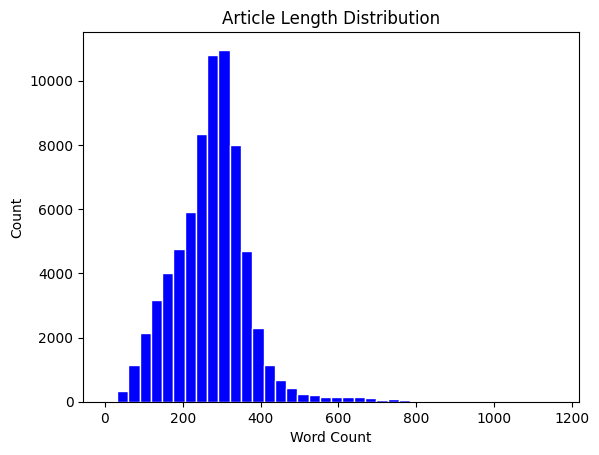

In [21]:
plt.hist(train['article_words'], bins=40, color='blue',edgecolor='white')
plt.title('Article Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Count')
plt.show()
        

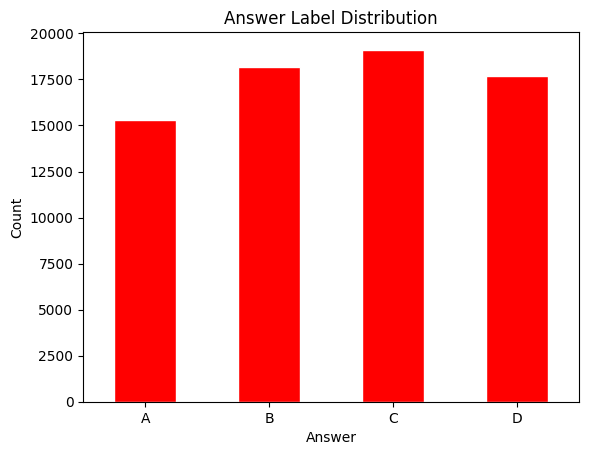

In [14]:
train['answer'].value_counts().sort_index().plot(kind='bar',color='red',edgecolor='white')
plt.title('Answer Label Distribution')
plt.xlabel('Answer')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
                                                 

In [22]:
train[[
    'article_words',
    'question_words',
    'a_words',
    'b_words',
    'c_words',
    'd_words',
    'avg_option_words'
]].describe().round(2)

,article_words,question_words,a_words,b_words,c_words,d_words,avg_option_words
count,70292.00,70292.00,70292.00,70292.00,70292.00,70292.00,70292.00
mean,272.90,9.04,5.43,5.64,5.80,5.92,5.70
std,97.59,3.38,3.30,3.40,3.47,3.57,3.18
min,2.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,215.00,7.00,3.00,3.00,3.00,3.00,3.00
50%,277.00,9.00,5.00,5.00,6.00,6.00,5.75
75%,324.00,11.00,8.00,8.00,8.00,8.00,8.00
max,1161.00,61.00,91.00,105.00,48.00,67.00,70.00


In [23]:
def find_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print("column:", column)
    print("lower limit:", lower)
    print("upper limit:", upper)
    print("total outliers:", len(outliers))

    return outliers

article_outliers = find_outliers(train, 'article_words')
question_outliers = find_outliers(train, 'question_words')

column: article_words
lower limit: 51.5
upper limit: 487.5
total outliers: 1745
column: question_words
lower limit: 1.0
upper limit: 17.0
total outliers: 1258


In [24]:
corr = train[[
    'article_words',
    'question_words',
    'a_words',
    'b_words',
    'c_words',
    'd_words',
    'avg_option_words'
]].corr()

corr.round(2)

,article_words,question_words,a_words,b_words,c_words,d_words,avg_option_words
article_words,1.00,0.19,0.25,0.25,0.25,0.25,0.27
question_words,0.19,1.00,-0.01,-0.01,-0.01,-0.01,-0.01
a_words,0.25,-0.01,1.00,0.83,0.81,0.77,0.92
b_words,0.25,-0.01,0.83,1.00,0.83,0.80,0.93
c_words,0.25,-0.01,0.81,0.83,1.00,0.82,0.93
d_words,0.25,-0.01,0.77,0.80,0.82,1.00,0.92
avg_option_words,0.27,-0.01,0.92,0.93,0.93,0.92,1.00


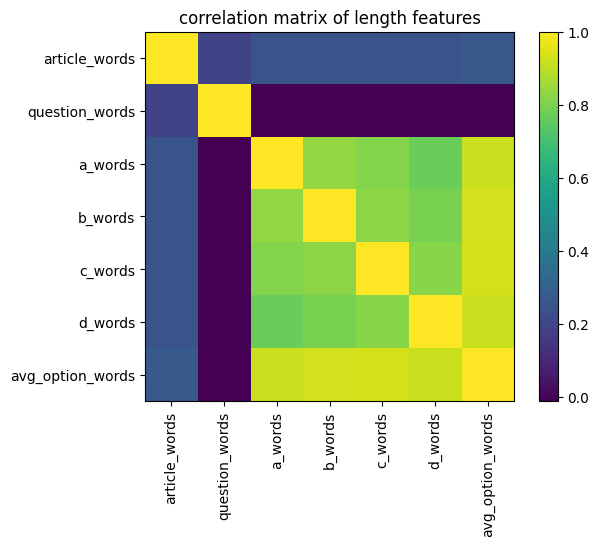

In [25]:
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('correlation matrix of length features')
plt.show()

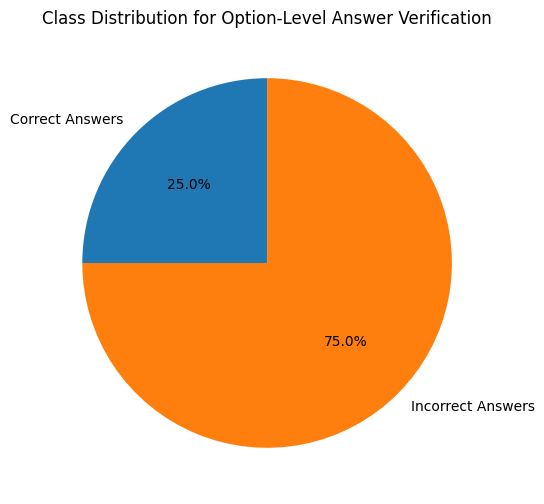

In [15]:
import matplotlib.pyplot as plt

labels = ["Correct Answers", "Incorrect Answers"]
sizes = [25, 75]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Class Distribution for Option-Level Answer Verification")

plt.show()

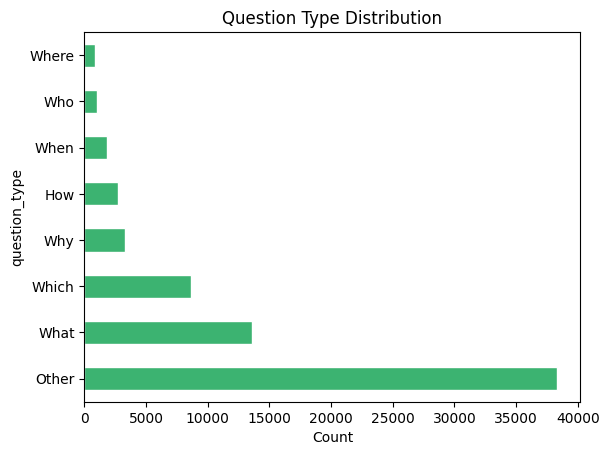

In [27]:
def get_type(q):
    q = str(q).lower()
    for w in ['what', 'which', 'who', 'when', 'where', 'why', 'how']:
        if q.startswith(w):
            return w.capitalize()
    return 'Other'

train['question_type'] = train['question'].apply(get_type)

train['question_type'].value_counts().plot(
    kind='barh',
    color='mediumseagreen',
    edgecolor='white'
)

plt.title('Question Type Distribution')
plt.xlabel('Count')
plt.show()

In [7]:
total = len(train) + len(dev) + len(test)

print('Split Summary')
print(f'Train : {len(train)} rows  ({len(train)/total*100:.1f}%)')
print(f'Dev   : {len(dev)} rows  ({len(dev)/total*100:.1f}%)')
print(f'Test  : {len(test)} rows  ({len(test)/total*100:.1f}%)')

Split Summary
Train : 70292 rows  (80.0%)
Dev   : 8787 rows  (10.0%)
Test  : 8787 rows  (10.0%)


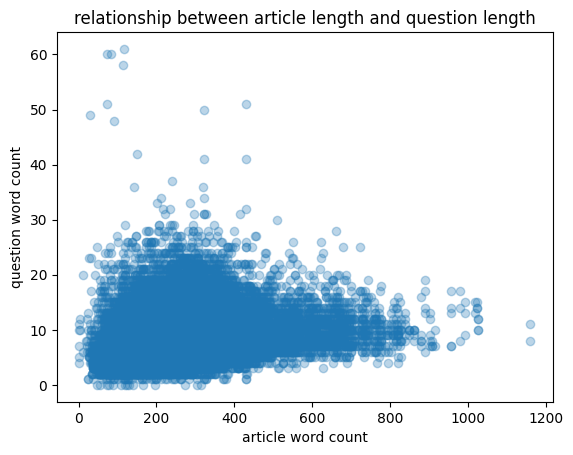

In [26]:
plt.scatter(train['article_words'], train['question_words'], alpha=0.3)

plt.title('relationship between article length and question length')
plt.xlabel('article word count')
plt.ylabel('question word count')
plt.show()

In [10]:
summary = {
    'Metric': [
        'Train rows', 'Dev rows', 'Test rows',
        'Avg article length', 'Most common question type',
        'Answer balance', 'Missing values'
    ],
    'Value': [
        len(train), len(dev), len(test),
        f"{train['article_words'].mean():.0f} words",
        train['question_type'].value_counts().index[0],
        'Balanced (stratified split)',
        'None'
    ]
}

pd.DataFrame(summary)

,Metric,Value
0,Train rows,70292
1,Dev rows,8787
2,Test rows,8787
3,Avg article length,273 words
4,Most common question type,Other
5,Answer balance,Balanced (stratified split)
6,Missing values,None
